In [1]:
import h5py
import halotools
import os
import copy
import warnings
import numpy as np
import math
from astropy.modeling import Fittable1DModel, Parameter,models,fitting
import pickle
import warnings
import numpy.ma as ma
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import spearmanr,kendalltau,pearsonr,ks_2samp
import palettable
import deepdish as dd
import matplotlib.cm as cm

from matplotlib.collections import LineCollection
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import colors
from astroML.stats import binned_statistic_2d
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import LinearRegression

from astropy.utils.console import ProgressBar
from astropy.table import QTable,hstack
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

In [2]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
data_dir='/Users/xushuo/work/Submit/CenvsSat/Data/'

In [3]:
with open(data_dir+"galaxies_tng300_072_hmc_13_venn_diagram_test.txt",'rb') as f: 
    tab_venn=pickle.load(f)

In [4]:
with open(data_dir+"galaxies_tng300_072_hmc_13_mhalo_c_split_f_1.txt",'rb') as f: 
    tab_cmh1=pickle.load(f)

In [5]:
tab_cmh1

top_numb,ks_mh,ks_mh_low,ks_mh_upp,dm_c,dm_c_low,dm_c_upp,dist_mah,dist_mah_err,lens_ratio_inn,lens_ratio_inn_err,lens_ratio_med,lens_ratio_med_err,lens_ratio_out,lens_ratio_out_err
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
800,0.08058608058608059,0.07326007326007326,0.13186813186813187,2.8734064889890094,2.802074622535656,2.9552179415279274,2.027803506035962,0.08751491125682163,0.7894513536575353,0.03171799169329857,1.0231503636420454,0.060362918765740806,1.0623799405481715,0.09258993334578183
600,0.0625,0.07692307692307693,0.13942307692307693,2.8263872368941083,2.728443960136671,2.926354479448895,2.0502375021394936,0.12756449283063162,0.7791617373375643,0.033120722336169355,1.0182239800057702,0.06299760421349586,1.054175211917528,0.09096535670011487
400,0.08148148148148149,0.0962962962962963,0.17037037037037037,2.9952249894156022,2.8817256974654253,3.190855666356112,2.066043851945088,0.16164917202817217,0.7462793670043987,0.036611175645873115,0.9967730859009603,0.06842441095053833,1.0463085820060214,0.10695730421732007
200,0.14705882352941177,0.1323529411764706,0.23529411764705882,2.959631023051557,2.7588354384455607,3.1173910783439345,1.9838794993701345,0.1983752233413048,0.7297805811617535,0.04386777874466473,0.970964699071563,0.07842811596823389,0.9037825561168286,0.10084941661414155


In [6]:
with open(data_dir+"galaxies_tng300_072_hmc_13_richness_split_test_f_1.txt",'rb') as f: 
    tab_rich1=pickle.load(f)

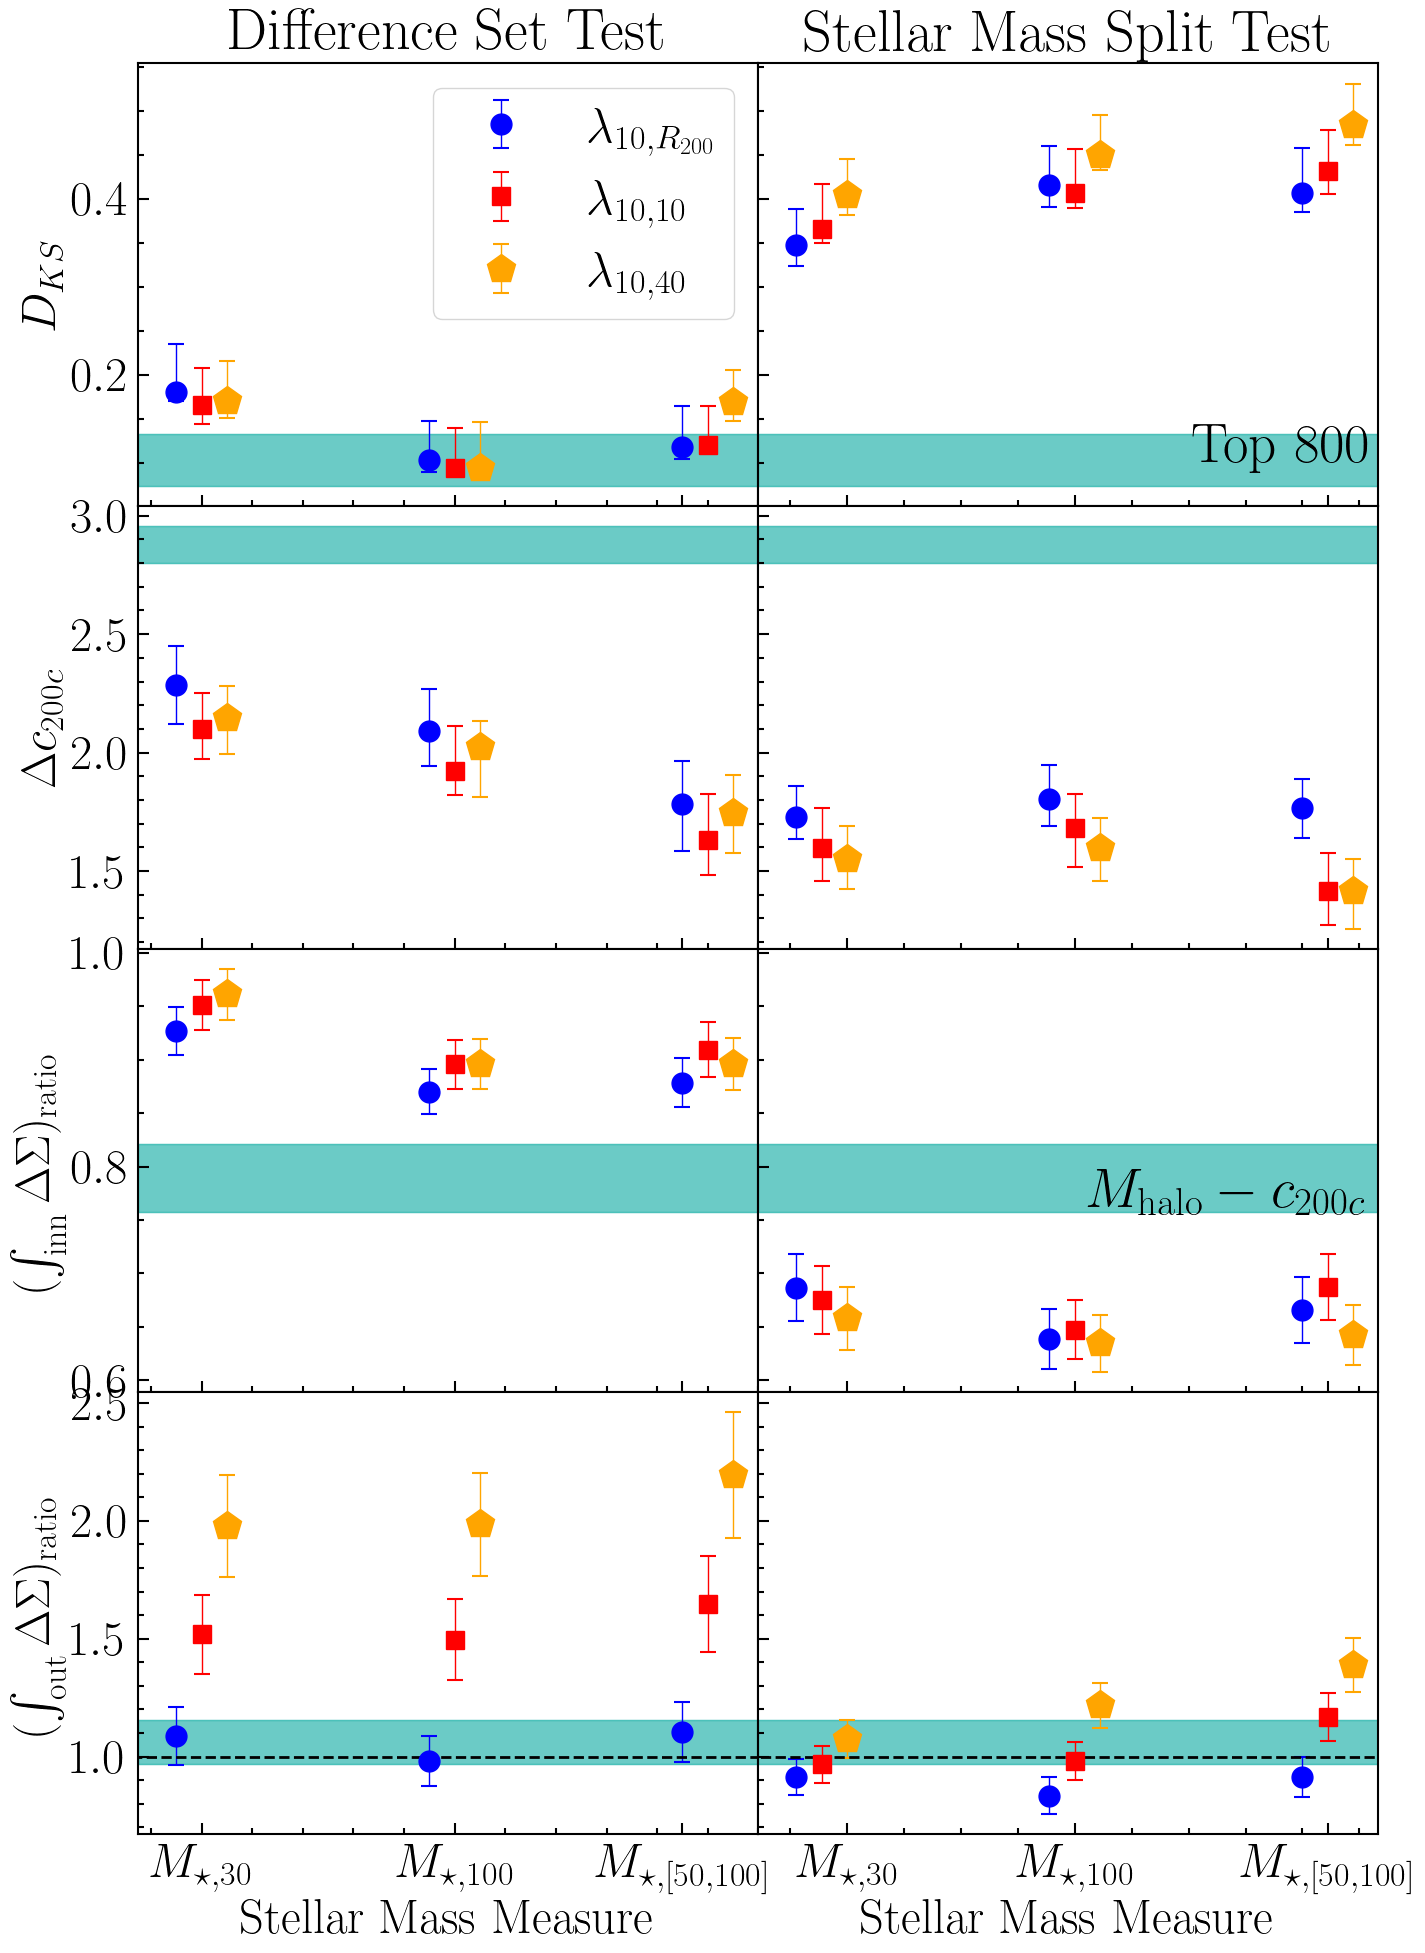

In [7]:
fig=plt.figure(figsize=(16,23))
gs = fig.add_gridspec(4,2, hspace=0, wspace=0,width_ratios=(0.3,0.3))
axlist=gs.subplots(sharey='row',sharex='col')
color_list=['blue','red','orange']
markerlist=['o','s','p','P','H','X','D','v','*','8','>']
sizelist=np.asarray([10,9,14,12,12,9,9,9,9,9,9])*1.5
name0_list=['richness_cut_r200_10','richness_cut_r200_10_xy_10','richness_cut_r200_10_xy_40']
label_list=[r'$\lambda_{10,R_{200}}$',r'$\lambda_{10,10}$',r'$\lambda_{10,40}$']
term_list=['ks_mh','dm_c','lens_ratio_inn','lens_ratio_out']
ylabel_list=[r'$D_{KS}$',r'$\Delta c_{200c}$',r'$(\int_{\rm inn}\Delta\Sigma)_{\rm ratio}$',r'$(\int_{\rm out}\Delta\Sigma)_{\rm ratio}$']
for ii in range(3):
    col=color_list[ii]
    mark=markerlist[ii]
    name1=name0_list[ii]
    label=label_list[ii]
    size=sizelist[ii]
    top_numb=800
    mask_v=(tab_venn['name1']==name1)&(tab_venn['top_numb']==top_numb)
    mask_s=(tab_rich1['name1']==name1)&(tab_rich1['top_numb']==top_numb)
    mask_c=(tab_cmh1['top_numb']==top_numb)
    for j in range(4):
        term=term_list[j]
        if j<2:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],
                                 yerr=(tab_venn[mask_v][term]-tab_venn[mask_v][term+'_low'],tab_venn[mask_v][term+'_upp']-tab_venn[mask_v][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],
                                 yerr=(tab_rich1[mask_s][term]-tab_rich1[mask_s][term+'_low'],tab_rich1[mask_s][term+'_upp']-tab_rich1[mask_s][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term+'_low'][0],tab_cmh1[mask_c][term+'_upp'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term+'_low'][0],tab_cmh1[mask_c][term+'_upp'][0],alpha=0.3,color='lightseagreen')
            
        elif j<3:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],yerr=tab_venn[mask_v][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],yerr=tab_rich1[mask_s][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
        else:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],yerr=tab_venn[mask_v][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],yerr=tab_rich1[mask_s][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')

for j in range(4):
    axlist[j,0].set_ylabel(ylabel_list[j])
    if j>=3:
        axlist[j,0].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
        axlist[j,1].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
axlist[-1,0].set_xticks([1,2,2.9],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,0].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,1].set_xticks([1.1,2,3],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,1].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,0].set_xlim(0.75,3.2)
axlist[-1,1].set_xlim(0.75,3.2)
axlist[0,0].legend(ncol=1)
axlist[0,0].set_title(r'\rm Difference Set Test')
axlist[0,1].set_title(r'\rm Stellar Mass Split Test')
ax=axlist[0,1]
ax.text(0.7,0.1,r'\rm Top %d'%top_numb,transform=ax.transAxes,fontsize=40)
ax=axlist[2,1]
ax.text(0.53,0.42,r'$M_{\rm halo}-c_{200c}$',transform=ax.transAxes,fontsize=40)
plt.savefig(fig_dir+"FigA2.pdf",dpi=150)

In [22]:
tab_venn[mask_v]['ks_mh_low']

0.21518987341772153
0.13302752293577982
0.12871287128712872


Text(0.53, 0.42, '$M_{\\rm halo}-c_{200c}$')

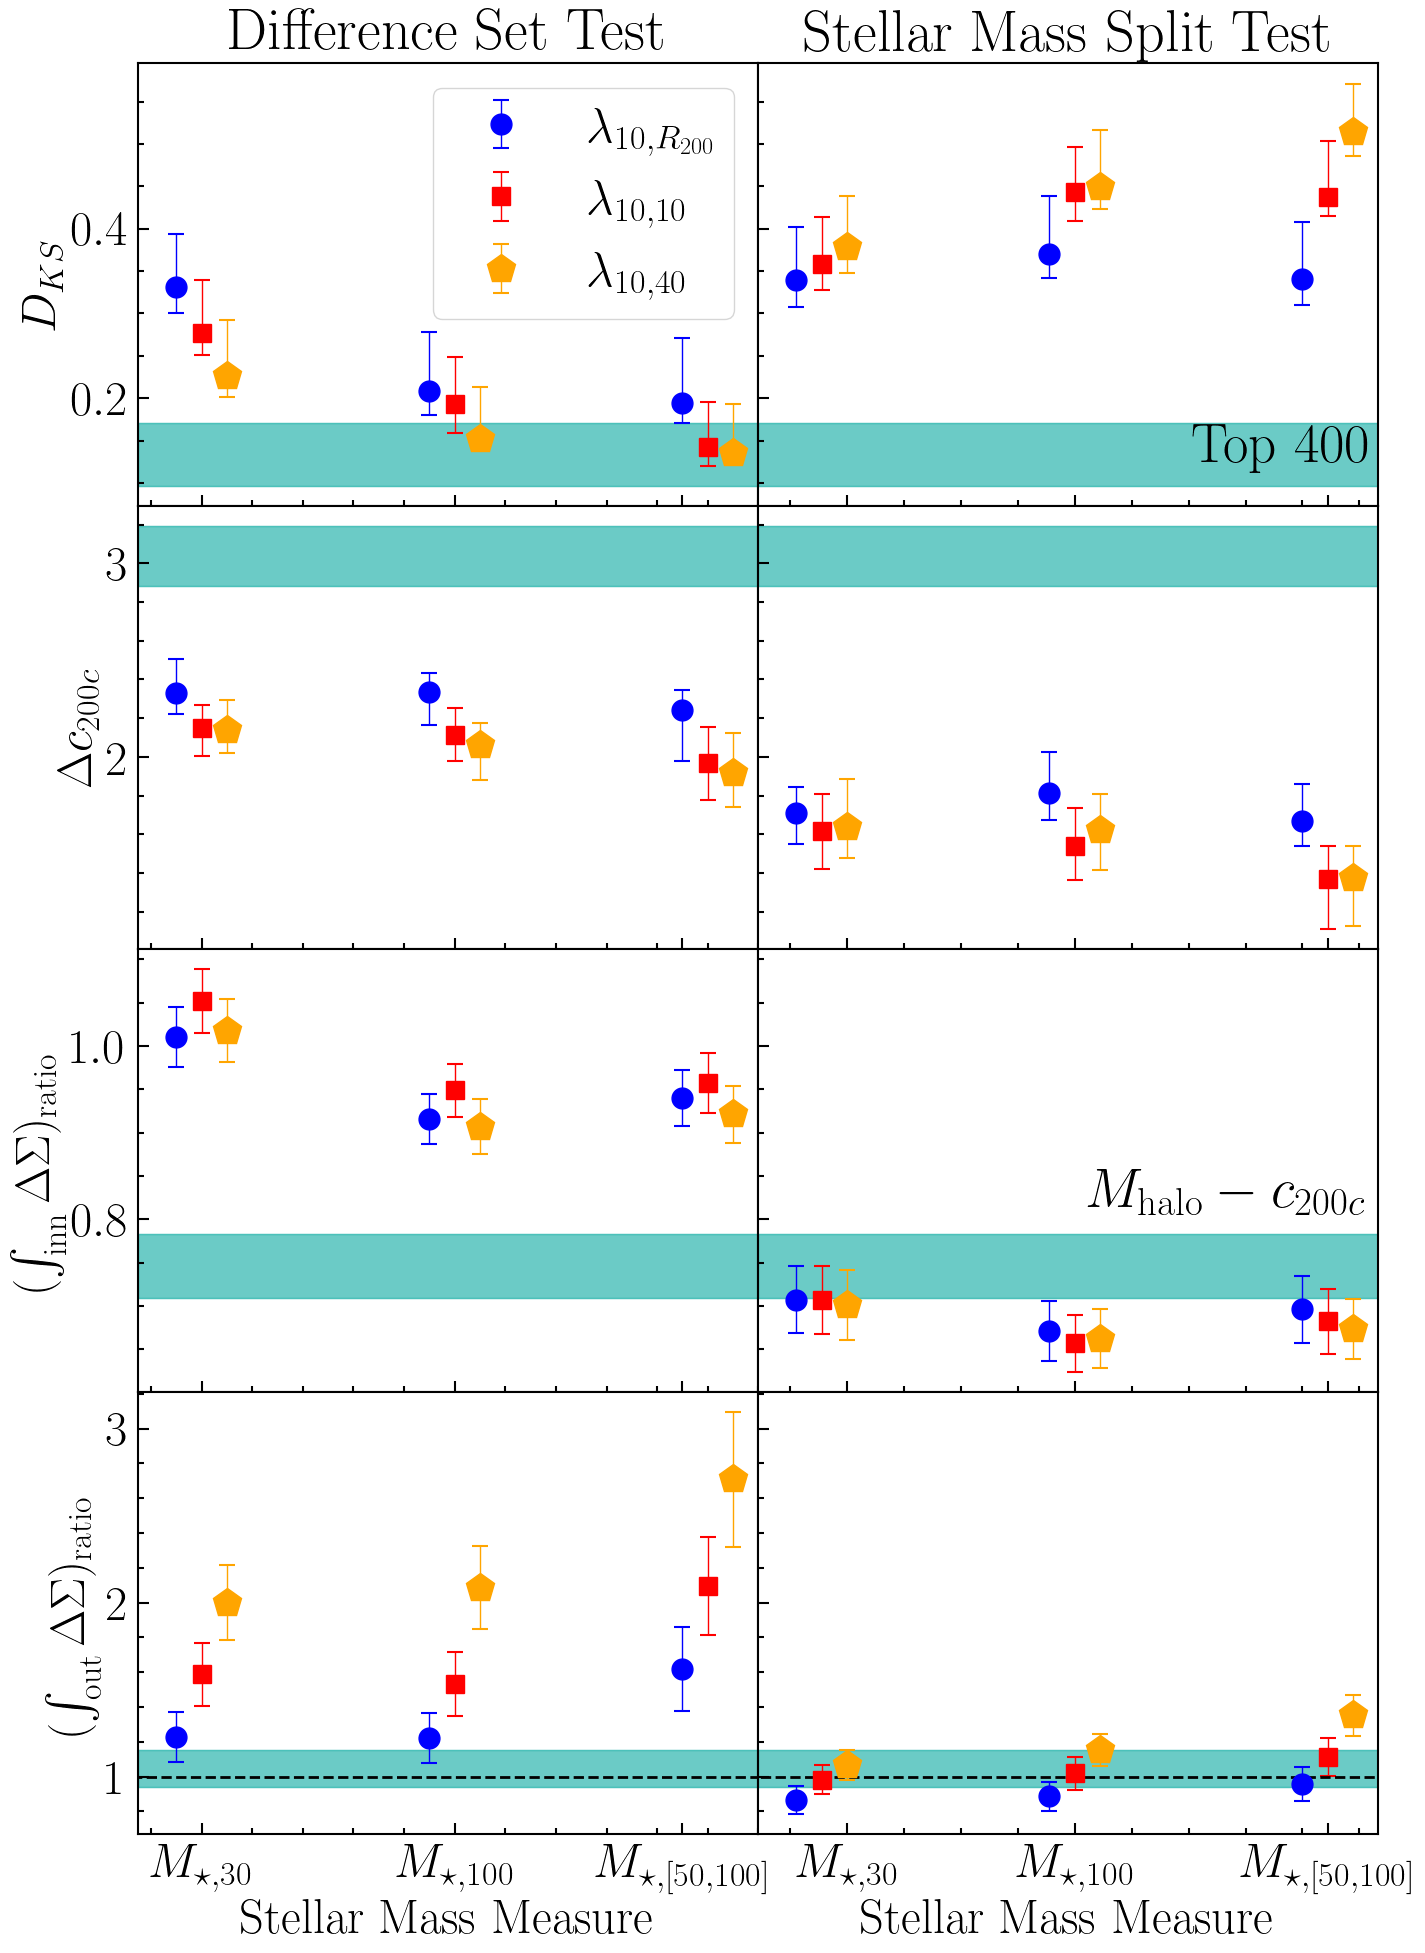

In [9]:
fig=plt.figure(figsize=(16,23))
gs = fig.add_gridspec(4,2, hspace=0, wspace=0,width_ratios=(0.3,0.3))
axlist=gs.subplots(sharey='row',sharex='col')
color_list=['blue','red','orange']
markerlist=['o','s','p','P','H','X','D','v','*','8','>']
sizelist=np.asarray([10,9,14,12,12,9,9,9,9,9,9])*1.5
name0_list=['richness_cut_r200_10','richness_cut_r200_10_xy_10','richness_cut_r200_10_xy_40']
label_list=[r'$\lambda_{10,R_{200}}$',r'$\lambda_{10,10}$',r'$\lambda_{10,40}$']
term_list=['ks_mh','dm_c','lens_ratio_inn','lens_ratio_out']
ylabel_list=[r'$D_{KS}$',r'$\Delta c_{200c}$',r'$(\int_{\rm inn}\Delta\Sigma)_{\rm ratio}$',r'$(\int_{\rm out}\Delta\Sigma)_{\rm ratio}$']
for ii in range(3):
    col=color_list[ii]
    mark=markerlist[ii]
    name1=name0_list[ii]
    label=label_list[ii]
    size=sizelist[ii]
    top_numb=400
    mask_v=(tab_venn['name1']==name1)&(tab_venn['top_numb']==top_numb)
    mask_s=(tab_rich1['name1']==name1)&(tab_rich1['top_numb']==top_numb)
    mask_c=(tab_cmh1['top_numb']==top_numb)
    for j in range(4):
        term=term_list[j]
        if j<2:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],
                                 yerr=(tab_venn[mask_v][term]-tab_venn[mask_v][term+'_low'],tab_venn[mask_v][term+'_upp']-tab_venn[mask_v][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],
                                 yerr=(tab_rich1[mask_s][term]-tab_rich1[mask_s][term+'_low'],tab_rich1[mask_s][term+'_upp']-tab_rich1[mask_s][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term+'_low'][0],tab_cmh1[mask_c][term+'_upp'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term+'_low'][0],tab_cmh1[mask_c][term+'_upp'][0],alpha=0.3,color='lightseagreen')
            
        elif j<3:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],yerr=tab_venn[mask_v][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],yerr=tab_rich1[mask_s][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
        else:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],yerr=tab_venn[mask_v][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],yerr=tab_rich1[mask_s][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')

for j in range(4):
    axlist[j,0].set_ylabel(ylabel_list[j])
    if j>=3:
        axlist[j,0].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
        axlist[j,1].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
axlist[-1,0].set_xticks([1,2,2.9],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,0].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,1].set_xticks([1.1,2,3],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,1].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,0].set_xlim(0.75,3.2)
axlist[-1,1].set_xlim(0.75,3.2)
axlist[0,0].legend(ncol=1)
axlist[0,0].set_title(r'\rm Difference Set Test')
axlist[0,1].set_title(r'\rm Stellar Mass Split Test')
ax=axlist[0,1]
ax.text(0.7,0.1,r'\rm Top %d'%top_numb,transform=ax.transAxes,fontsize=40)
ax=axlist[2,1]
ax.text(0.53,0.42,r'$M_{\rm halo}-c_{200c}$',transform=ax.transAxes,fontsize=40)


Text(0.53, 0.42, '$M_{\\rm halo}-c_{200c}$')

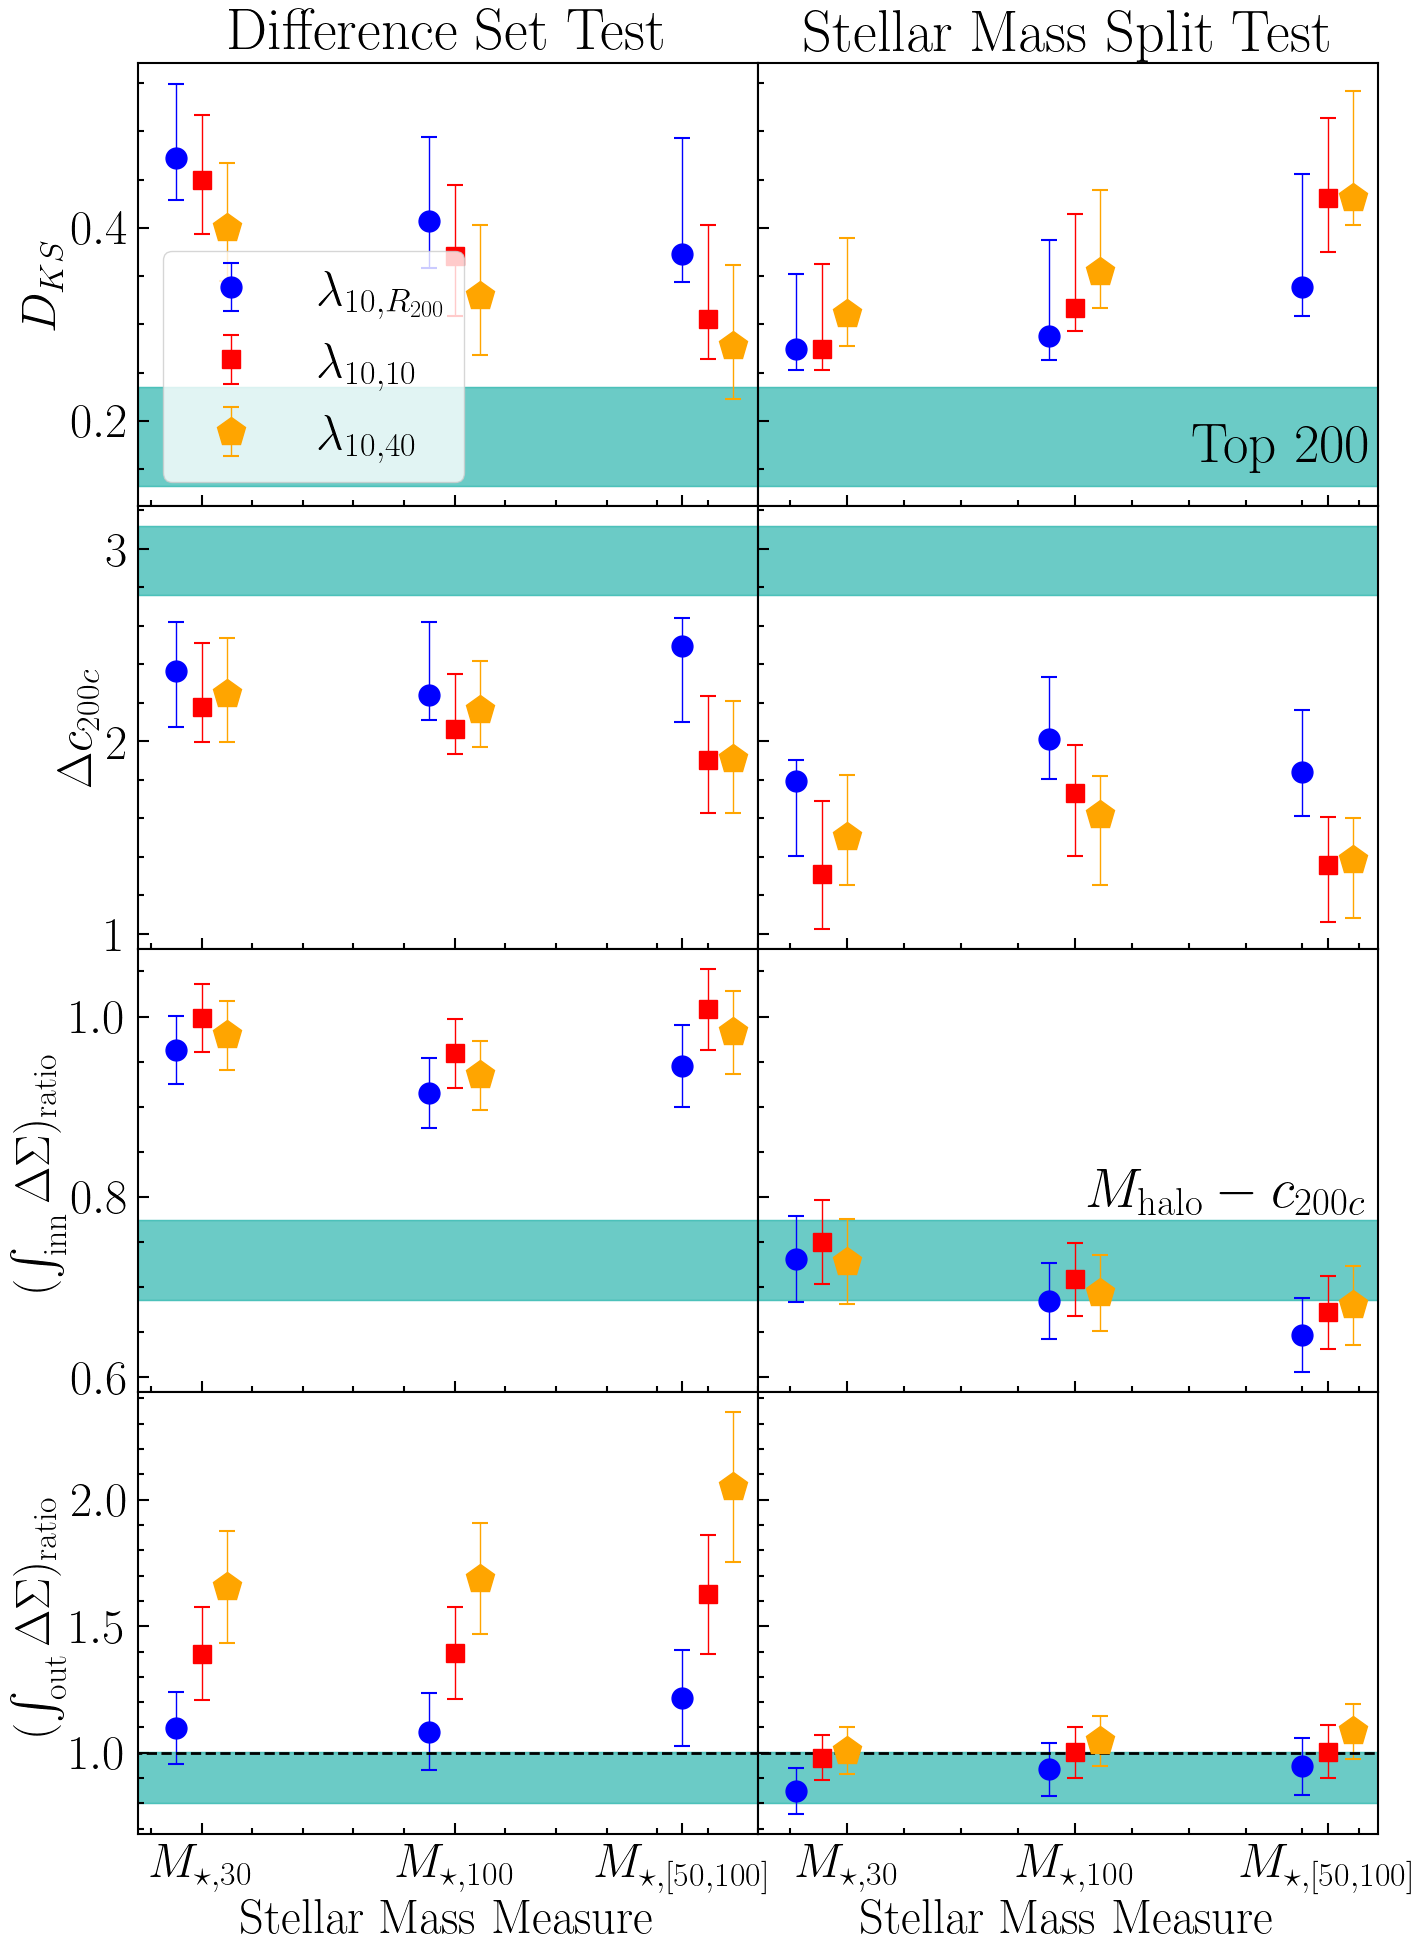

In [10]:
fig=plt.figure(figsize=(16,23))
gs = fig.add_gridspec(4,2, hspace=0, wspace=0,width_ratios=(0.3,0.3))
axlist=gs.subplots(sharey='row',sharex='col')
color_list=['blue','red','orange']
markerlist=['o','s','p','P','H','X','D','v','*','8','>']
sizelist=np.asarray([10,9,14,12,12,9,9,9,9,9,9])*1.5
name0_list=['richness_cut_r200_10','richness_cut_r200_10_xy_10','richness_cut_r200_10_xy_40']
label_list=[r'$\lambda_{10,R_{200}}$',r'$\lambda_{10,10}$',r'$\lambda_{10,40}$']
term_list=['ks_mh','dm_c','lens_ratio_inn','lens_ratio_out']
ylabel_list=[r'$D_{KS}$',r'$\Delta c_{200c}$',r'$(\int_{\rm inn}\Delta\Sigma)_{\rm ratio}$',r'$(\int_{\rm out}\Delta\Sigma)_{\rm ratio}$']
for ii in range(3):
    col=color_list[ii]
    mark=markerlist[ii]
    name1=name0_list[ii]
    label=label_list[ii]
    size=sizelist[ii]
    top_numb=200
    mask_v=(tab_venn['name1']==name1)&(tab_venn['top_numb']==top_numb)
    mask_s=(tab_rich1['name1']==name1)&(tab_rich1['top_numb']==top_numb)
    mask_c=(tab_cmh1['top_numb']==top_numb)
    for j in range(4):
        term=term_list[j]
        if j<2:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],
                                 yerr=(tab_venn[mask_v][term]-tab_venn[mask_v][term+'_low'],tab_venn[mask_v][term+'_upp']-tab_venn[mask_v][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],
                                 yerr=(tab_rich1[mask_s][term]-tab_rich1[mask_s][term+'_low'],tab_rich1[mask_s][term+'_upp']-tab_rich1[mask_s][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term+'_low'][0],tab_cmh1[mask_c][term+'_upp'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term+'_low'][0],tab_cmh1[mask_c][term+'_upp'][0],alpha=0.3,color='lightseagreen')
            
        elif j<3:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],yerr=tab_venn[mask_v][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],yerr=tab_rich1[mask_s][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
        else:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],yerr=tab_venn[mask_v][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],yerr=tab_rich1[mask_s][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')

for j in range(4):
    axlist[j,0].set_ylabel(ylabel_list[j])
    if j>=3:
        axlist[j,0].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
        axlist[j,1].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
axlist[-1,0].set_xticks([1,2,2.9],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,0].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,1].set_xticks([1.1,2,3],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,1].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,0].set_xlim(0.75,3.2)
axlist[-1,1].set_xlim(0.75,3.2)
axlist[0,0].legend(ncol=1)
axlist[0,0].set_title(r'\rm Difference Set Test')
axlist[0,1].set_title(r'\rm Stellar Mass Split Test')
ax=axlist[0,1]
ax.text(0.7,0.1,r'\rm Top %d'%top_numb,transform=ax.transAxes,fontsize=40)
ax=axlist[2,1]
ax.text(0.53,0.42,r'$M_{\rm halo}-c_{200c}$',transform=ax.transAxes,fontsize=40)


In [8]:
tab_cmh1

top_numb,ks_mh,ks_mh_low,ks_mh_upp,dm_c,dm_c_low,dm_c_upp,dist_mah,dist_mah_err,lens_ratio_inn,lens_ratio_inn_err,lens_ratio_med,lens_ratio_med_err,lens_ratio_out,lens_ratio_out_err
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
800,0.08058608058608059,0.07326007326007326,0.13186813186813187,2.8734064889890094,2.802074622535656,2.9552179415279274,2.027803506035962,0.08751491125682163,0.7894513536575353,0.03171799169329857,1.0231503636420454,0.060362918765740806,1.0623799405481715,0.09258993334578183
600,0.0625,0.07692307692307693,0.13942307692307693,2.8263872368941083,2.728443960136671,2.926354479448895,2.0502375021394936,0.12756449283063162,0.7791617373375643,0.033120722336169355,1.0182239800057702,0.06299760421349586,1.054175211917528,0.09096535670011487
400,0.08148148148148149,0.0962962962962963,0.17037037037037037,2.9952249894156022,2.8817256974654253,3.190855666356112,2.066043851945088,0.16164917202817217,0.7462793670043987,0.036611175645873115,0.9967730859009603,0.06842441095053833,1.0463085820060214,0.10695730421732007
200,0.14705882352941177,0.1323529411764706,0.23529411764705882,2.959631023051557,2.7588354384455607,3.1173910783439345,1.9838794993701345,0.1983752233413048,0.7297805811617535,0.04386777874466473,0.970964699071563,0.07842811596823389,0.9037825561168286,0.10084941661414155


Text(0.53, 0.42, '$M_{\\rm halo}-c_{200c}$')

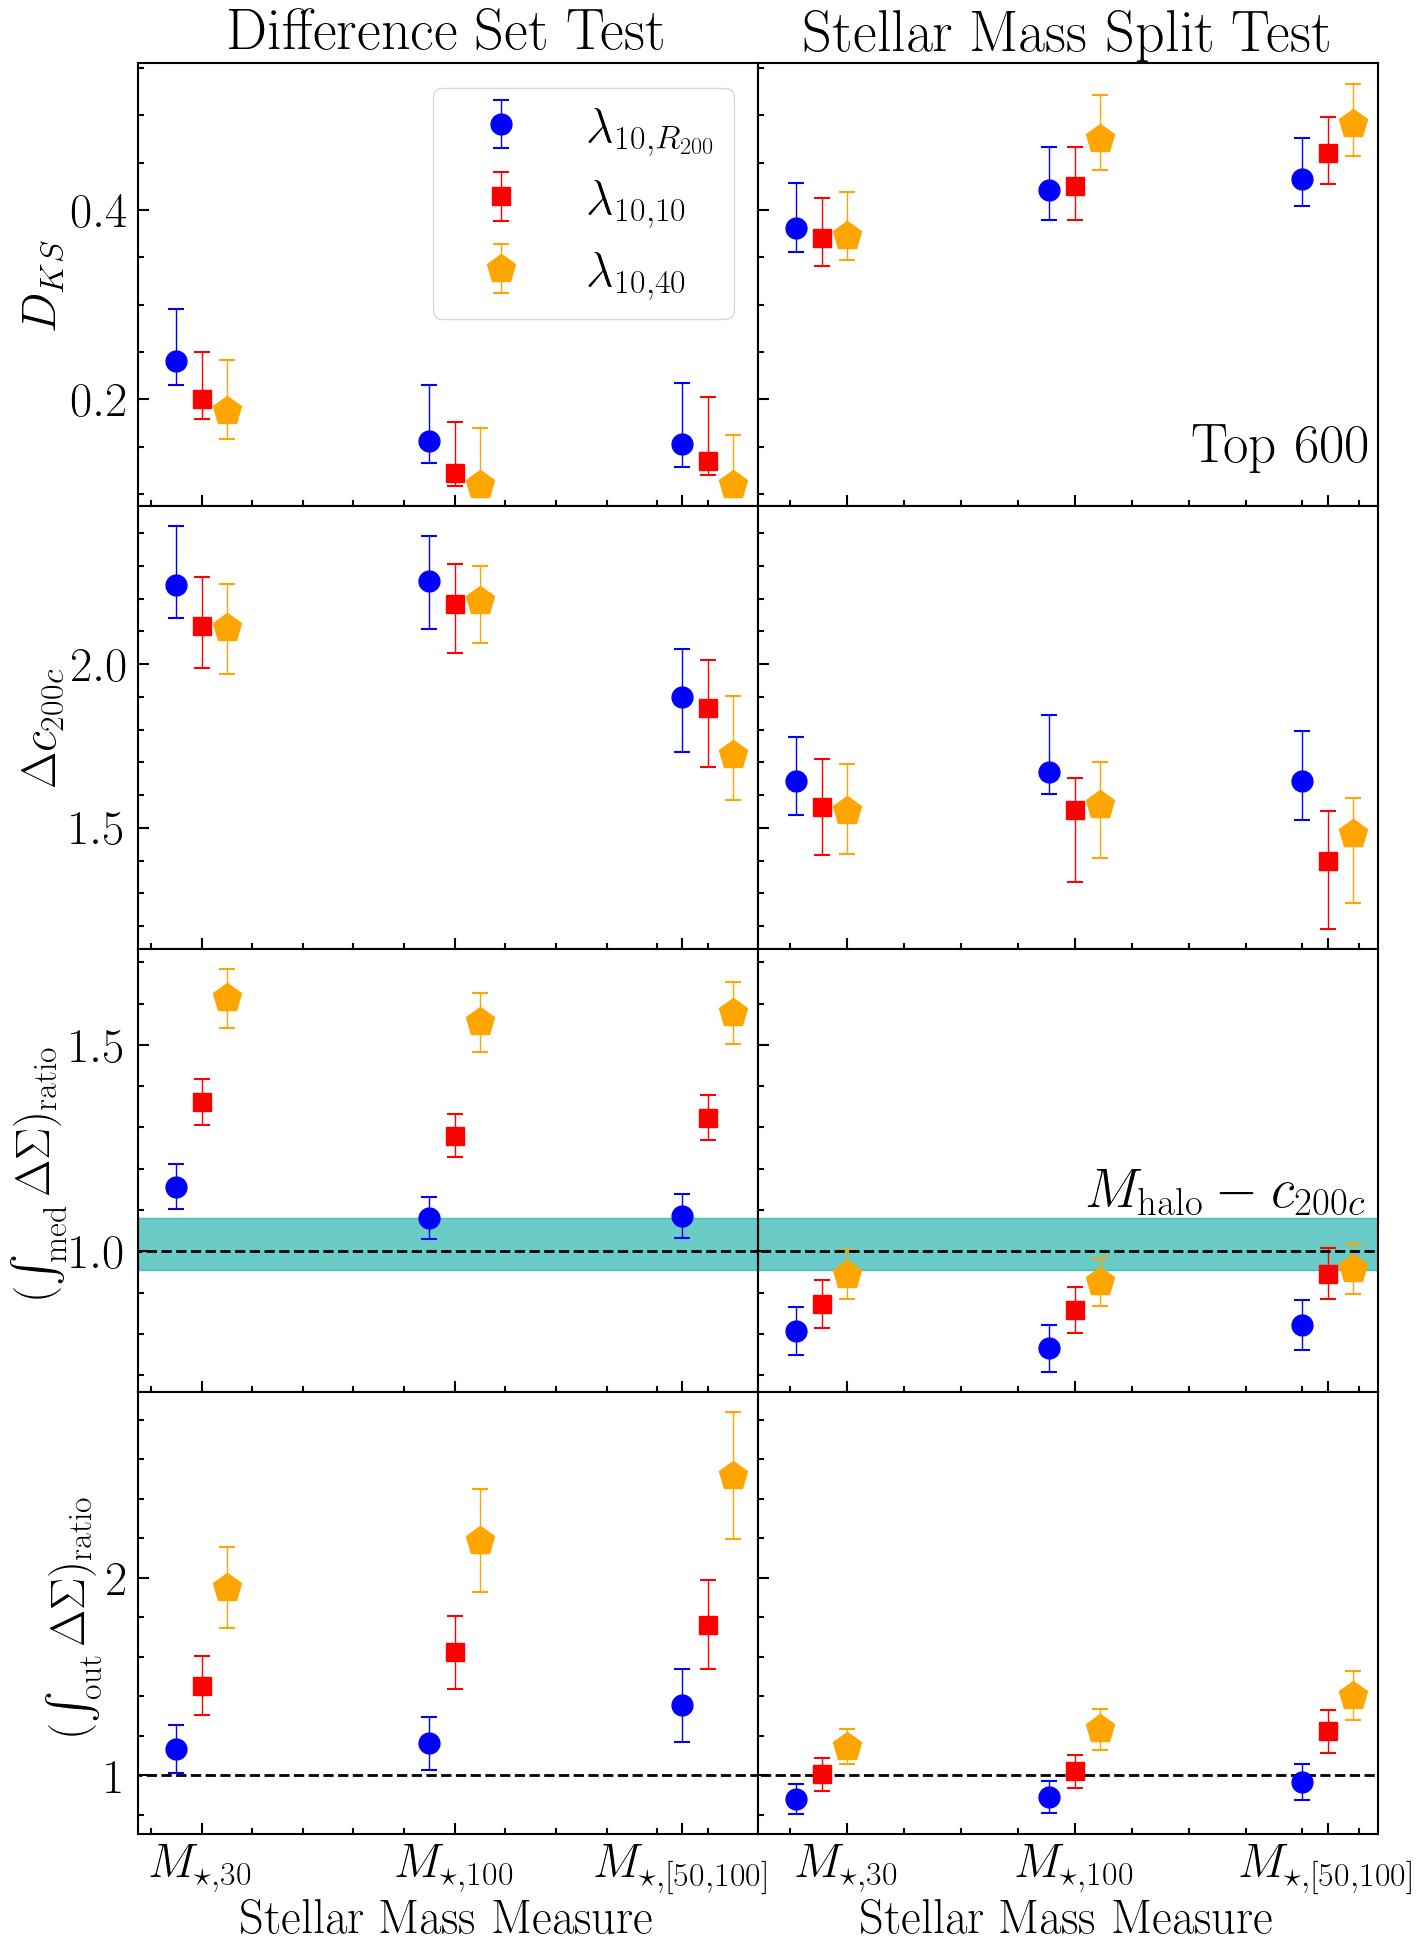

In [11]:
fig=plt.figure(figsize=(16,23))
gs = fig.add_gridspec(4,2, hspace=0, wspace=0,width_ratios=(0.3,0.3))
axlist=gs.subplots(sharey='row',sharex='col')
color_list=['blue','red','orange']
markerlist=['o','s','p','P','H','X','D','v','*','8','>']
sizelist=np.asarray([10,9,14,12,12,9,9,9,9,9,9])*1.5
name0_list=['richness_cut_r200_10','richness_cut_r200_10_xy_10','richness_cut_r200_10_xy_40']
label_list=[r'$\lambda_{10,R_{200}}$',r'$\lambda_{10,10}$',r'$\lambda_{10,40}$']
term_list=['ks_mh','dm_c','lens_ratio_med','lens_ratio_out']
ylabel_list=[r'$D_{KS}$',r'$\Delta c_{200c}$',r'$(\int_{\rm med}\Delta\Sigma)_{\rm ratio}$',r'$(\int_{\rm out}\Delta\Sigma)_{\rm ratio}$']
for ii in range(3):
    col=color_list[ii]
    mark=markerlist[ii]
    name1=name0_list[ii]
    label=label_list[ii]
    size=sizelist[ii]
    top_numb=600
    mask_v=(tab_venn['name1']==name1)&(tab_venn['top_numb']==top_numb)
    mask_s=(tab_rich1['name1']==name1)&(tab_rich1['top_numb']==top_numb)
    mask_c=(tab_cmh1['top_numb']==top_numb)
    for j in range(4):
        term=term_list[j]
        if j<2:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],
                                 yerr=(tab_venn[mask_v][term]-tab_venn[mask_v][term+'_low'],tab_venn[mask_v][term+'_upp']-tab_venn[mask_v][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],
                                 yerr=(tab_rich1[mask_s][term]-tab_rich1[mask_s][term+'_low'],tab_rich1[mask_s][term+'_upp']-tab_rich1[mask_s][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            
        elif j<3:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],yerr=tab_venn[mask_v][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],yerr=tab_rich1[mask_s][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
        else:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],yerr=tab_venn[mask_v][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],yerr=tab_rich1[mask_s][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)

for j in range(4):
    axlist[j,0].set_ylabel(ylabel_list[j])
    if j>=2:
        axlist[j,0].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
        axlist[j,1].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
axlist[-1,0].set_xticks([1,2,2.9],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,0].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,1].set_xticks([1.1,2,3],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,1].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,0].set_xlim(0.75,3.2)
axlist[-1,1].set_xlim(0.75,3.2)
axlist[0,0].legend(ncol=1)
axlist[0,0].set_title(r'\rm Difference Set Test')
axlist[0,1].set_title(r'\rm Stellar Mass Split Test')
ax=axlist[0,1]
ax.text(0.7,0.1,r'\rm Top %d'%top_numb,transform=ax.transAxes,fontsize=40)
ax=axlist[2,1]
ax.text(0.53,0.42,r'$M_{\rm halo}-c_{200c}$',transform=ax.transAxes,fontsize=40)

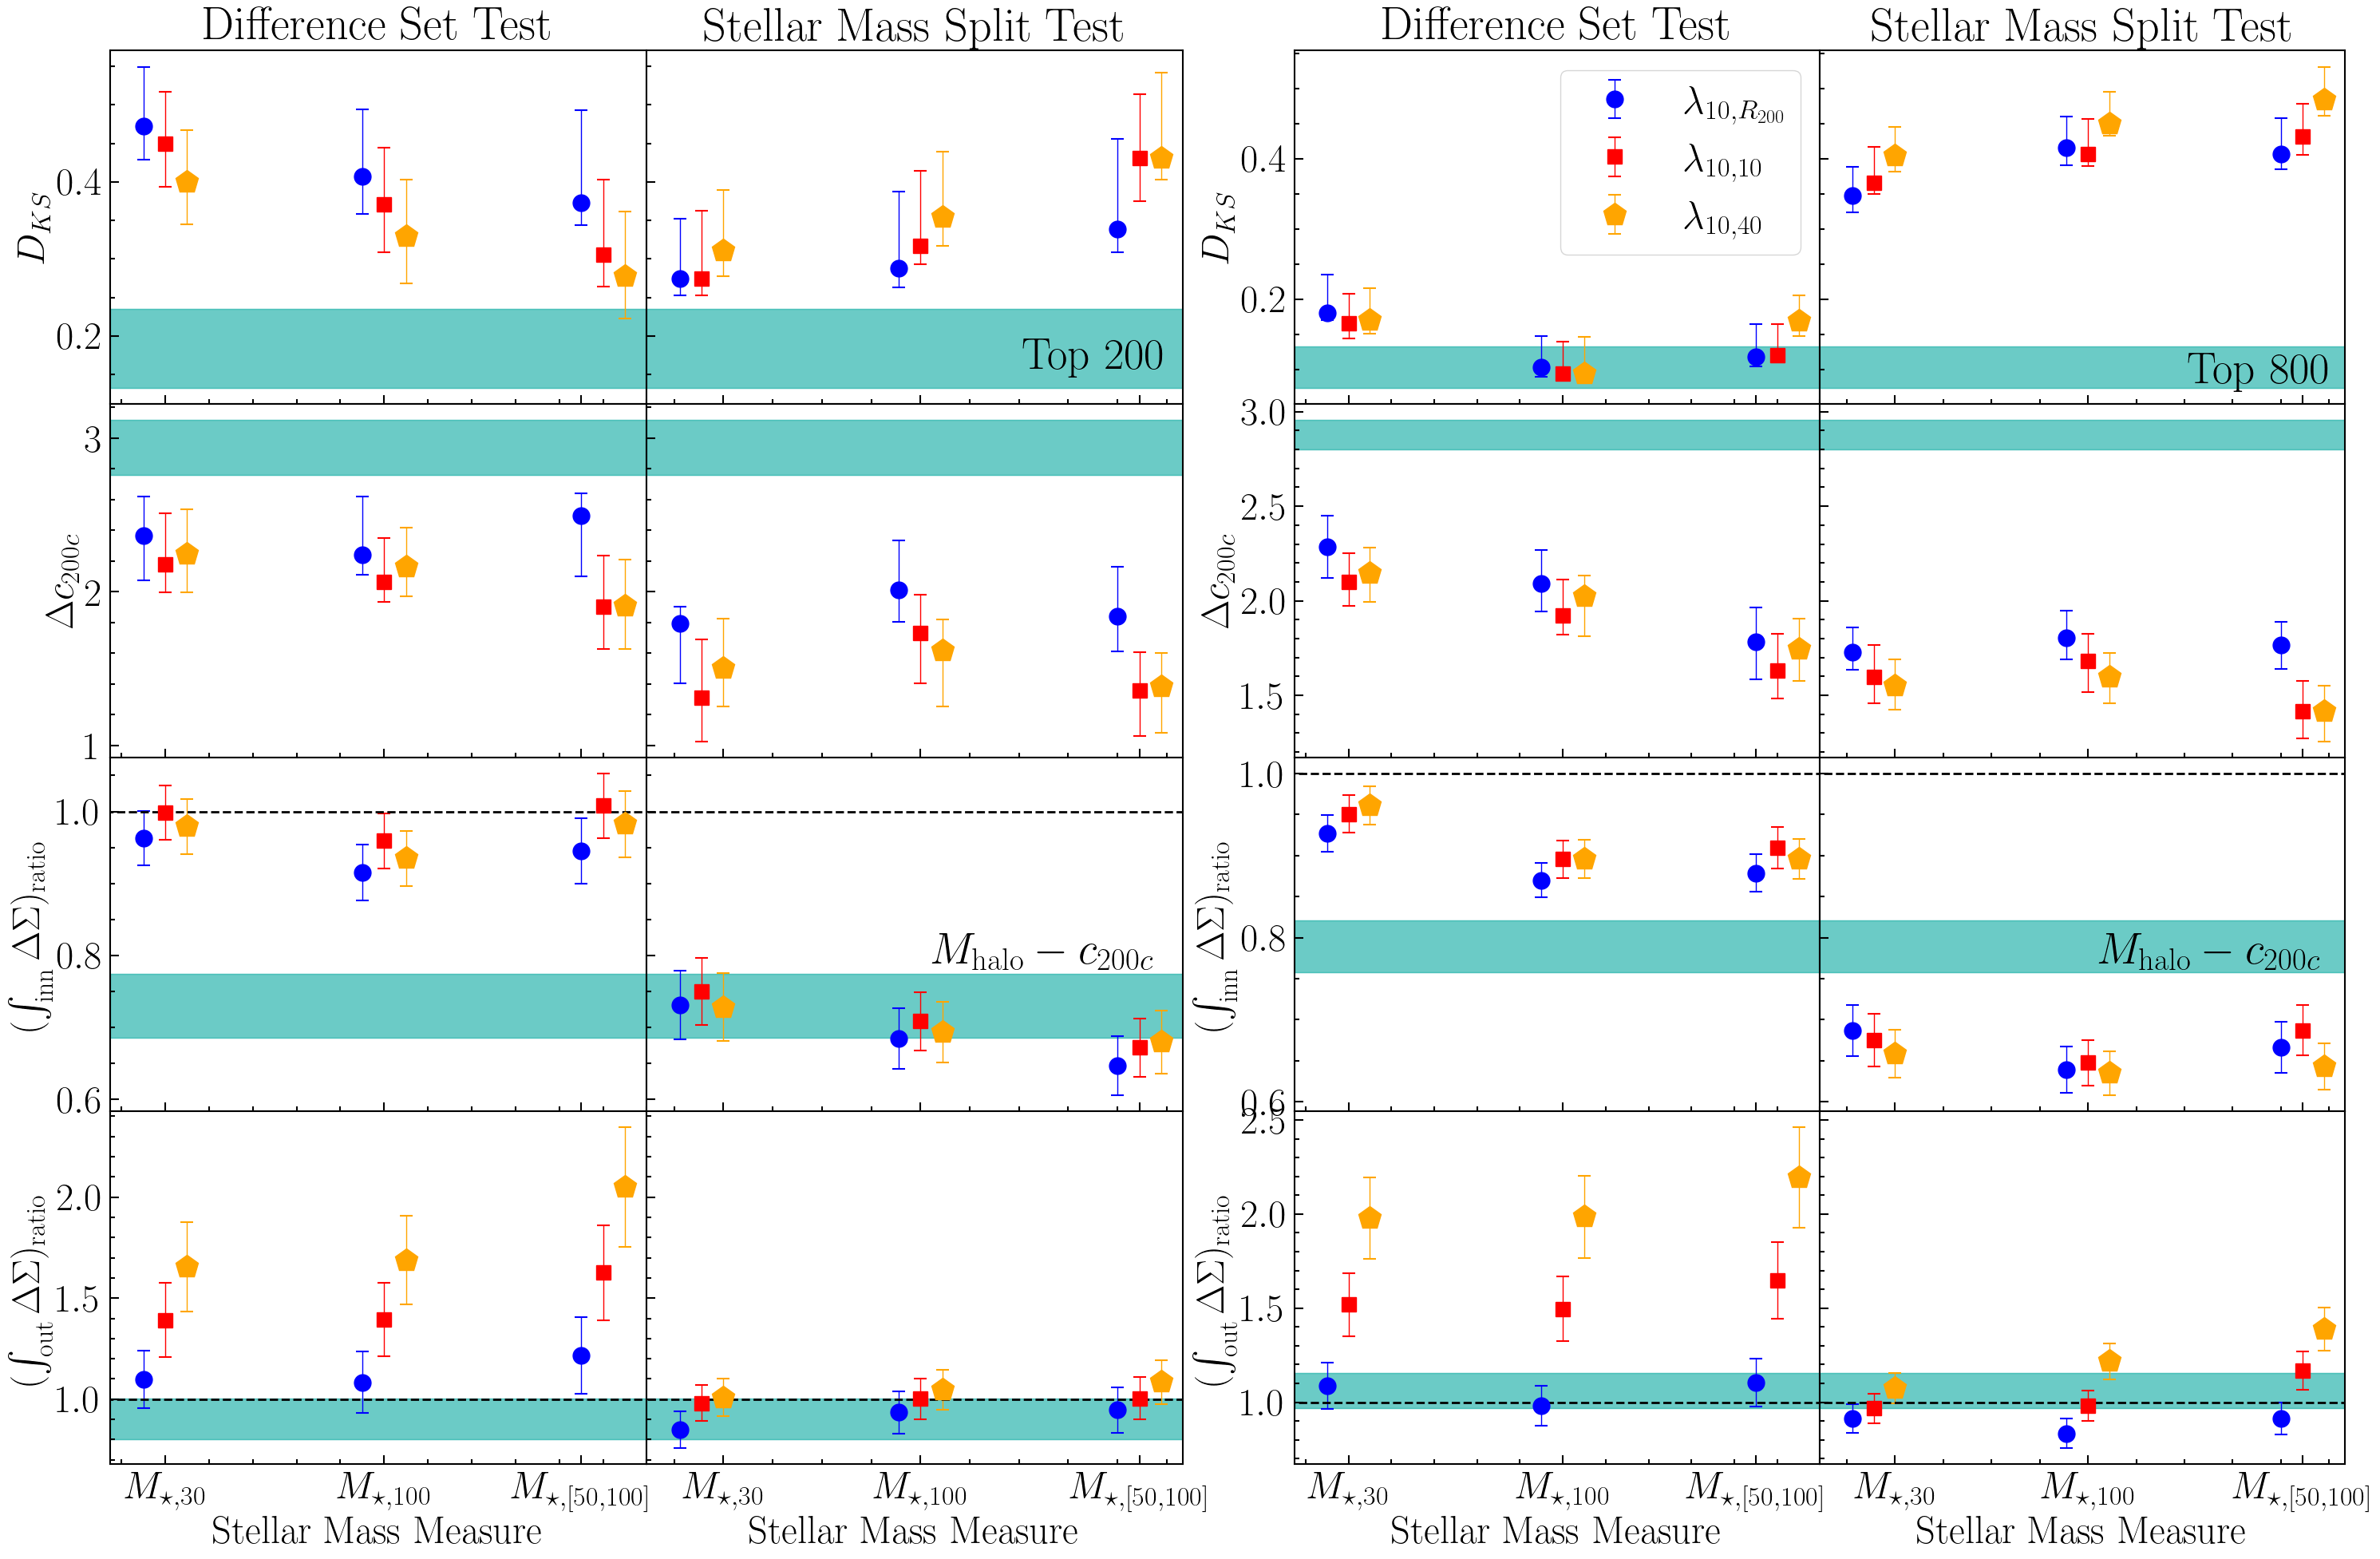

In [23]:
fig=plt.figure(figsize=(28,23))
gs = fig.add_gridspec(4,2, left=0,right=0.48, hspace=0, wspace=0,width_ratios=(0.3,0.3))
gs0 = fig.add_gridspec(4,2, left=0.53,right=1, hspace=0, wspace=0,width_ratios=(0.3,0.3))
axlist=gs.subplots(sharey='row',sharex='col')
color_list=['blue','red','orange']
markerlist=['o','s','p','P','H','X','D','v','*','8','>']
sizelist=np.asarray([10,9,14,12,12,9,9,9,9,9,9])*1.5
name0_list=['richness_cut_r200_10','richness_cut_r200_10_xy_10','richness_cut_r200_10_xy_40']
label_list=[r'$\lambda_{10,R_{200}}$',r'$\lambda_{10,10}$',r'$\lambda_{10,40}$']
term_list=['ks_mh','dm_c','lens_ratio_inn','lens_ratio_out']
ylabel_list=[r'$D_{KS}$',r'$\Delta c_{200c}$',r'$(\int_{\rm inn}\Delta\Sigma)_{\rm ratio}$',r'$(\int_{\rm out}\Delta\Sigma)_{\rm ratio}$']
for ii in range(3):
    col=color_list[ii]
    mark=markerlist[ii]
    name1=name0_list[ii]
    label=label_list[ii]
    size=sizelist[ii]
    top_numb=200
    mask_v=(tab_venn['name1']==name1)&(tab_venn['top_numb']==top_numb)
    mask_s=(tab_rich1['name1']==name1)&(tab_rich1['top_numb']==top_numb)
    mask_c=(tab_cmh1['top_numb']==top_numb)
    for j in range(4):
        term=term_list[j]
        if j<2:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],
                                 yerr=(tab_venn[mask_v][term]-tab_venn[mask_v][term+'_low'],tab_venn[mask_v][term+'_upp']-tab_venn[mask_v][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],
                                 yerr=(tab_rich1[mask_s][term]-tab_rich1[mask_s][term+'_low'],tab_rich1[mask_s][term+'_upp']-tab_rich1[mask_s][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term+'_low'][0],tab_cmh1[mask_c][term+'_upp'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term+'_low'][0],tab_cmh1[mask_c][term+'_upp'][0],alpha=0.3,color='lightseagreen')
            
        elif j<3:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],yerr=tab_venn[mask_v][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],yerr=tab_rich1[mask_s][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
        else:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],yerr=tab_venn[mask_v][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],yerr=tab_rich1[mask_s][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')

for j in range(4):
    axlist[j,0].set_ylabel(ylabel_list[j])
    if j>=2:
        axlist[j,0].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
        axlist[j,1].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
axlist[-1,0].set_xticks([1,2,2.9],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,0].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,1].set_xticks([1.1,2,3],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,1].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,0].set_xlim(0.75,3.2)
axlist[-1,1].set_xlim(0.75,3.2)
axlist[0,0].set_title(r'\rm Difference Set Test')
axlist[0,1].set_title(r'\rm Stellar Mass Split Test')
ax=axlist[0,1]
ax.text(0.7,0.1,r'\rm Top %d'%top_numb,transform=ax.transAxes,fontsize=40)
ax=axlist[2,1]
ax.text(0.53,0.42,r'$M_{\rm halo}-c_{200c}$',transform=ax.transAxes,fontsize=40)

axlist=gs0.subplots(sharey='row',sharex='col')
for ii in range(3):
    col=color_list[ii]
    mark=markerlist[ii]
    name1=name0_list[ii]
    label=label_list[ii]
    size=sizelist[ii]
    top_numb=800
    mask_v=(tab_venn['name1']==name1)&(tab_venn['top_numb']==top_numb)
    mask_s=(tab_rich1['name1']==name1)&(tab_rich1['top_numb']==top_numb)
    mask_c=(tab_cmh1['top_numb']==top_numb)
    for j in range(4):
        term=term_list[j]
        if j<2:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],
                                 yerr=(tab_venn[mask_v][term]-tab_venn[mask_v][term+'_low'],tab_venn[mask_v][term+'_upp']-tab_venn[mask_v][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],
                                 yerr=(tab_rich1[mask_s][term]-tab_rich1[mask_s][term+'_low'],tab_rich1[mask_s][term+'_upp']-tab_rich1[mask_s][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term+'_low'][0],tab_cmh1[mask_c][term+'_upp'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term+'_low'][0],tab_cmh1[mask_c][term+'_upp'][0],alpha=0.3,color='lightseagreen')
            
        elif j<3:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],yerr=tab_venn[mask_v][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],yerr=tab_rich1[mask_s][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
        else:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],yerr=tab_venn[mask_v][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],yerr=tab_rich1[mask_s][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')

for j in range(4):
    axlist[j,0].set_ylabel(ylabel_list[j])
    if j>=2:
        axlist[j,0].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
        axlist[j,1].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
axlist[-1,0].set_xticks([1,2,2.9],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,0].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,1].set_xticks([1.1,2,3],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,1].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,0].set_xlim(0.75,3.2)
axlist[-1,1].set_xlim(0.75,3.2)
axlist[0,0].legend(ncol=1)
axlist[0,0].set_title(r'\rm Difference Set Test')
axlist[0,1].set_title(r'\rm Stellar Mass Split Test')
ax=axlist[0,1]
ax.text(0.7,0.06,r'\rm Top %d'%top_numb,transform=ax.transAxes,fontsize=40)
ax=axlist[2,1]
ax.text(0.53,0.42,r'$M_{\rm halo}-c_{200c}$',transform=ax.transAxes,fontsize=40)

plt.savefig(fig_dir+"FigA2.pdf",dpi=150,bbox_inches='tight')